In [103]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set(style="whitegrid")


In [104]:
# Load Dataset
# ----------------------------------
df = pd.read_csv("C:\\Users\\hp\\Downloads\\BEFA58B_ALL_LATEST (1).csv")

# Rename columns
df.rename(columns={
    "DIM_TIME": "Year",
    "GEO_NAME_SHORT": "Country",
    "RATE_PER_100_N": "Rate"
}, inplace=True)

df = df[["Year", "Country", "DIM_SEX", "DIM_AGE", "Rate"]]

# Filter India
india_df = df[df["Country"] == "India"]


In [105]:
# ----------------------------------
# Data Cleaning
# ----------------------------------

print("Initial Shape:", df.shape)

# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Drop missing values (safe approach for your dataset)
df = df.dropna()

# Remove duplicates
df = df.drop_duplicates()

# Convert Year to numeric
df["Year"] = pd.to_numeric(df["Year"], errors="coerce")

# Convert Rate to numeric
df["Rate"] = pd.to_numeric(df["Rate"], errors="coerce")

# Drop rows where conversion failed
df = df.dropna(subset=["Year", "Rate"])

# Reset index
df = df.reset_index(drop=True)

print("\nCleaned Shape:", df.shape)

Initial Shape: (20790, 5)

Missing Values:
Year       0
Country    0
DIM_SEX    0
DIM_AGE    0
Rate       0
dtype: int64

Cleaned Shape: (20790, 5)


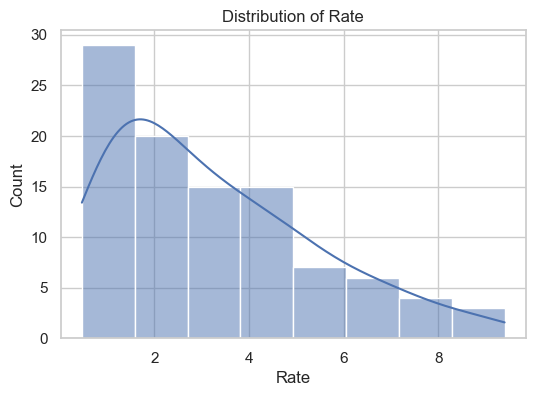

In [85]:
# EDA Section
# ----------------------------------

# 1. Distribution Plot
plt.figure(figsize=(6,4))
sns.histplot(india_df["Rate"], kde=True)
plt.title("Distribution of Rate")
plt.show()

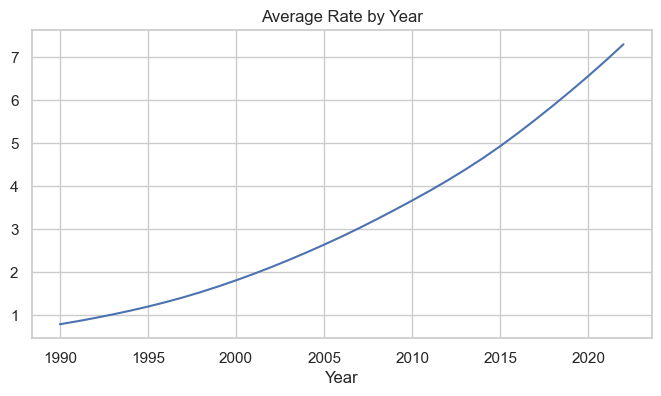

In [73]:
# 2. Average Rate by Year
avg_year = india_df.groupby("Year")["Rate"].mean()
plt.figure(figsize=(8,4))
avg_year.plot()
plt.title("Average Rate by Year")
plt.show()

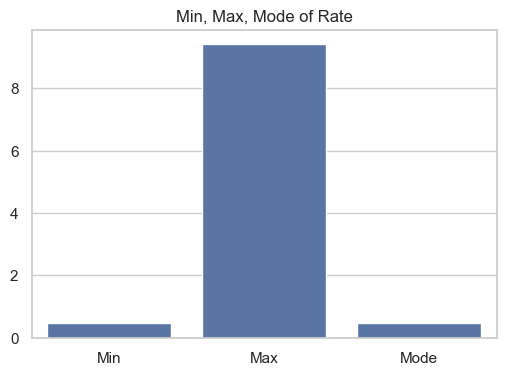

In [53]:
# 3. Min, Max, Mode
min_rate = india_df["Rate"].min()
max_rate = india_df["Rate"].max()
mode_rate = india_df["Rate"].mode()[0]

plt.figure(figsize=(6,4))
sns.barplot(x=["Min","Max","Mode"], y=[min_rate, max_rate, mode_rate])
plt.title("Min, Max, Mode of Rate")
plt.show()


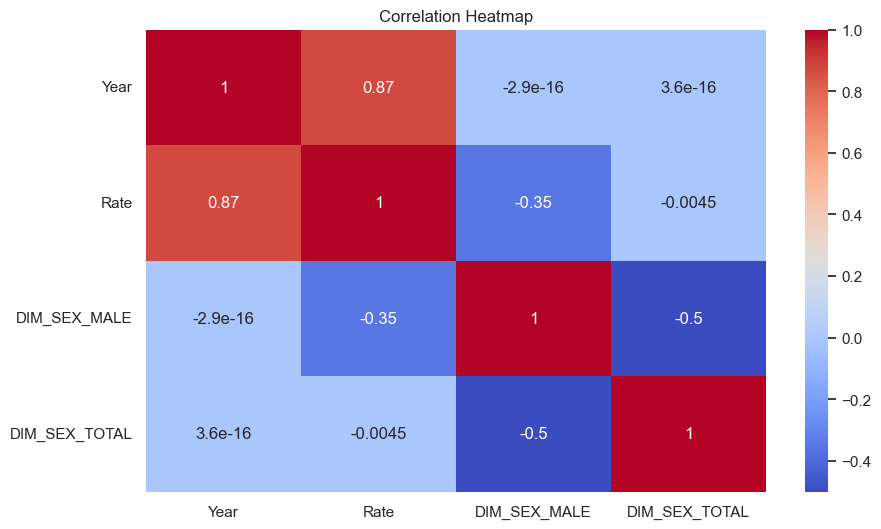

In [54]:
# 4. Correlation Heatmap
df_encoded = pd.get_dummies(india_df, drop_first=True)

plt.figure(figsize=(10,6))
sns.heatmap(df_encoded.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

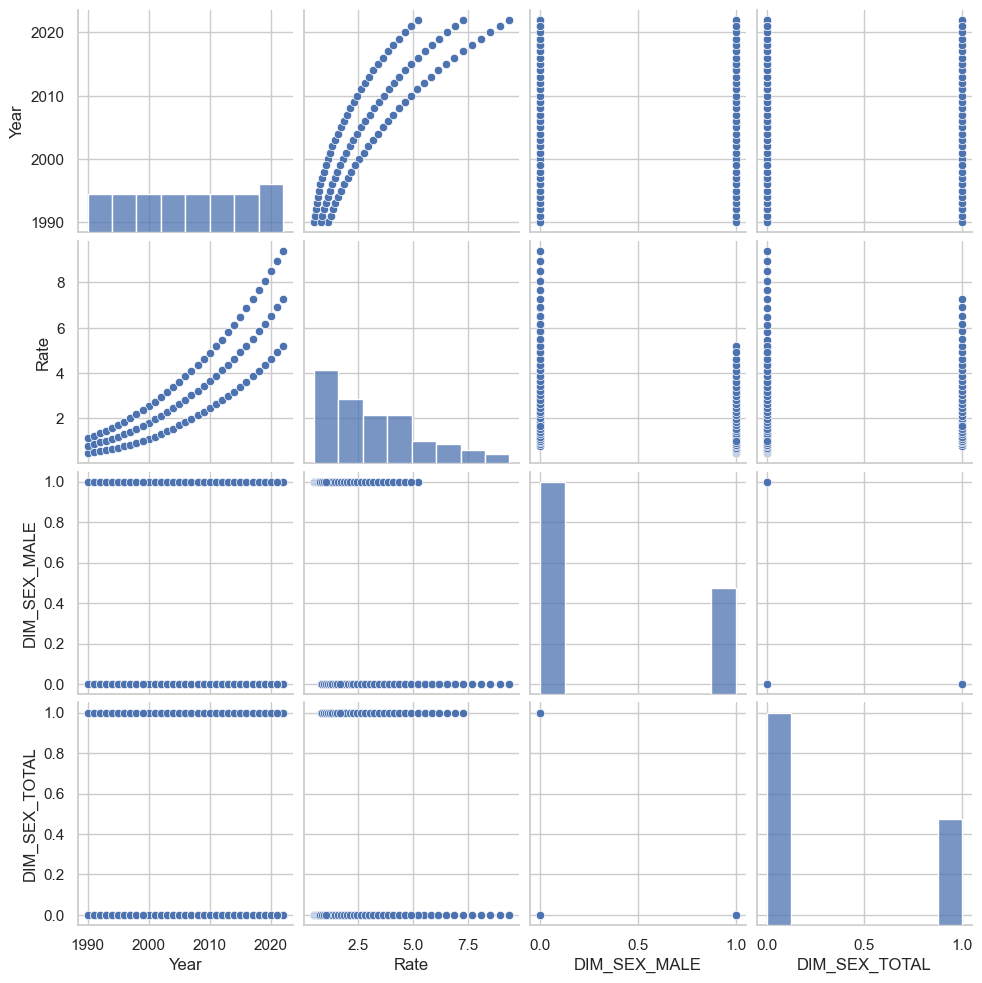

In [55]:

# 5. Pairplot
sns.pairplot(df_encoded)
plt.show()


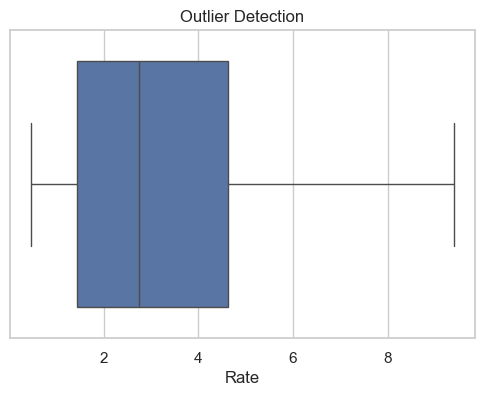

In [56]:
# 6. Outlier Detection (Boxplot)
plt.figure(figsize=(6,4))
sns.boxplot(x=india_df["Rate"])
plt.title("Outlier Detection")
plt.show()



In [99]:
# ----------------------------------
# Feature Engineering
# ----------------------------------

# Make a copy to avoid modifying original data
df_ml = df.copy()

# Check columns before encoding
print("Columns before encoding:", df_ml.columns.tolist())

# Apply one-hot encoding
df_ml = pd.get_dummies(
    df_ml,
    columns=["Country", "DIM_SEX", "DIM_AGE"],
    drop_first=True
)

# Check result
print("\nAfter Encoding:")
print("Shape:", df_ml.shape)
print("Sample Data:")
print(df_ml.head())


# ----------------------------------
# Define Features and Target
# ----------------------------------
X = df_ml.drop("Rate", axis=1)
y = df_ml["Rate"]

print("\nFeature Shape:", X.shape)
print("Target Shape:", y.shape)


# ----------------------------------
# Scaling
# ----------------------------------
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame for readability
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print("\nScaled Features:")
print(X_scaled.head())

Columns before encoding: ['Year', 'Country', 'DIM_SEX', 'DIM_AGE', 'Rate']

After Encoding:
Shape: (20790, 213)
Sample Data:
   Year       Rate  Country_Africa  Country_Albania  Country_Algeria  \
0  1990   2.923865           False            False            False   
1  1990  35.615239           False            False            False   
2  1990  25.662801           False            False            False   
3  1990  30.880660           False            False            False   
4  1990  19.299324           False            False            False   

   Country_American Samoa  Country_Americas  Country_Andorra  Country_Angola  \
0                   False             False            False           False   
1                   False             False            False           False   
2                   False             False            False           False   
3                   False             False            False           False   
4                   False             Fals

In [101]:
# ----------------------------------
# Model Training
# ----------------------------------

# Ensure X_scaled is DataFrame (not numpy array)
if not isinstance(X_scaled, pd.DataFrame):
    X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

# Check for missing values
print("Missing values in X:", X_scaled.isnull().sum().sum())
print("Missing values in y:", y.isnull().sum())

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print("\nTrain Shape:", X_train.shape)
print("Test Shape:", X_test.shape)

# Model training
model = LinearRegression()
model.fit(X_train, y_train)

print("\nModel training completed")

# Prediction
y_pred = model.predict(X_test)

print("Sample predictions:", y_pred[:5])

Missing values in X: 0
Missing values in y: 0

Train Shape: (16632, 212)
Test Shape: (4158, 212)

Model training completed
Sample predictions: [56.75945768 36.7535346  25.53840242  7.09103265 19.54757942]


In [102]:
# Model Evaluation
# ----------------------------------
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("R2:", r2)


MAE: 2.4908523716356954
MSE: 11.221613607599215
R2: 0.9398447654804812


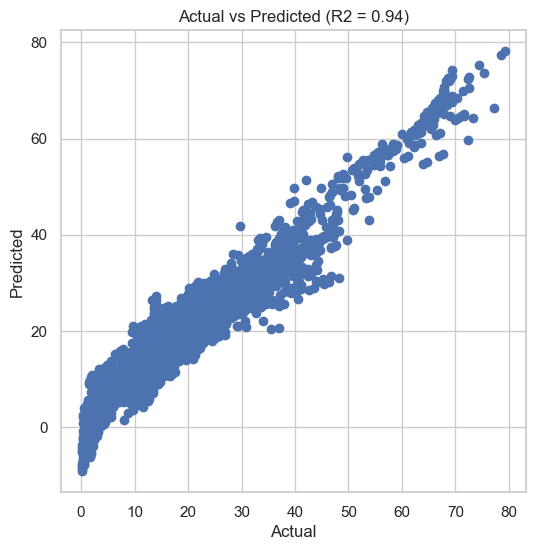

In [106]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred)

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title(f"Actual vs Predicted (R2 = {r2:.2f})")

plt.show()

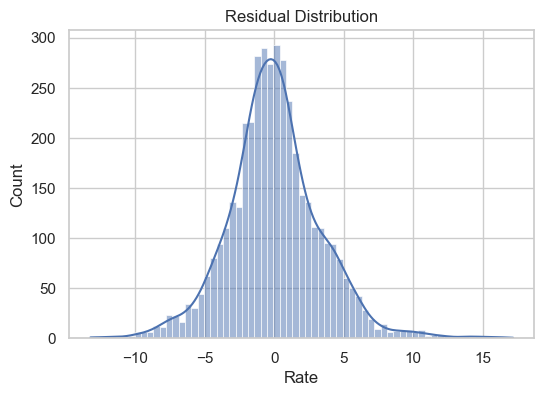

In [90]:
# Residual Distribution
# ----------------------------------
residuals = y_test - y_pred

plt.figure(figsize=(6,4))
sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")
plt.show()


In [91]:
# Model Comparison (Baseline vs Model)
# ----------------------------------
baseline_pred = [y_train.mean()] * len(y_test)
baseline_r2 = r2_score(y_test, baseline_pred)

print("Baseline R2:", baseline_r2)
print("Model R2:", r2)

Baseline R2: -7.307167296399797e-05
Model R2: 0.9398447654804812


In [92]:
# Conclusion
# ----------------------------------
print("\nConclusion:")
print("EDA revealed distribution patterns and outliers")
print("Feature engineering applied using encoding and scaling")
print("Linear regression model trained and evaluated")
print("Model performs better than baseline if R2 is higher")
print("Residual analysis shows prediction error distribution")


Conclusion:
EDA revealed distribution patterns and outliers
Feature engineering applied using encoding and scaling
Linear regression model trained and evaluated
Model performs better than baseline if R2 is higher
Residual analysis shows prediction error distribution
